# Première idée pour la modélisation 3D

In [1]:
import parcels
import cartopy
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
from parcels import FieldSet
from datetime import timedelta
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec

In [52]:
import os
import shutil

dossier = "Test"
os.makedirs(dossier, exist_ok=True)

for element in os.listdir(dossier):
    chemin_element = os.path.join(dossier, element)
    if os.path.isfile(chemin_element) or os.path.islink(chemin_element):
        os.remove(chemin_element)  # supprime le fichier ou le lien symbolique
    elif os.path.isdir(chemin_element):
        shutil.rmtree(chemin_element)  # supprime le sous-dossier et tout son contenu


# Integrate Rapid-mCDR model (OAE method) into 2D horizontal OceanParcels simulations with LL270 data

## 1) Define the Fieldset and variables required for continuous OAE simulation (alkalinity added daily in the initial cell of the ALK zero concentration field)

In [36]:
# Define the files to load depending on the time and depth
date = '1995-01'

# Define the data region and the time of the data
region = "ACC"

### 1) a. Load the U, V, DIC and ALK monthly fields at the desired time and depth from the LLC270 dataset

In [ ]:
# Definition of NetCDF files for U, V, W and ALK
path = "/Users/margheritacastellano/Documents/These-Recherche/SEMES/code/data"
filenames = {
    "U": f"{path}/UVEL_{date}_equal.nc",
    "V": f"{path}/VVEL_{date}_equal.nc",
    "W": f"{path}/WVEL_{date}.nc",
    "ALK": f"{path}/ALK_{date}.nc"
}

# Definition of variables and dimensions
variables = {
    "U": "UVEL",
    "V": "VVEL",
    "W": "WVEL",
    "ALK": "ALK"
}

dimensions = {
    "U": {"depth": "Depth", "lat": "Latitude", "lon": "Longitude", "time": "Time"},
    "V": {"depth": "Depth", "lat": "Latitude", "lon": "Longitude", "time": "Time"},
    "W": {"depth": "Depth", "lat": "Latitude", "lon": "Longitude", "time": "Time"},
    "ALK": {"depth": "Depth", "lat": "Latitude", "lon": "Longitude", "time": "Time"}
}

# Create the FieldSet for velocities U, V and W as well as the ALK concentration fields on an Arakawa C grid
fieldset = FieldSet.from_netcdf(
    filenames,
    variables,
    dimensions,
    mesh="spherical",
    allow_time_extrapolation=True
)

# Define the interpolation method for the UV velocity fields
fieldset.UV.interp_method = "cgrid_velocity"

# Define the same dimensions as the DIC and ALK fields for the ALK0 and DIC0 concentration fields
depth_C = fieldset.ALK.data.shape[1]
lon_C = fieldset.ALK.data.shape[3]
lat_C = fieldset.ALK.data.shape[2]

# Create a field full of zeros for the particle simulation in ALK0 field
data_alk0 = np.zeros([depth_C, lat_C, lon_C])
field_alk0 = parcels.Field("ALK0", data_alk0, grid=fieldset.ALK.grid)
fieldset.add_field(field_alk0)


# Convert the fields to float64
for f in [fieldset.U, fieldset.V, fieldset.W, fieldset.ALK0, fieldset.ALK]:
    f.data = f.data.astype(np.float64)

# (ALK0 is reconstructed from the per-particle columns and written per day in the
# run loop via fieldset.ALK0.write(...), so parcels' automatic field writing is off.)

K_diff_vertical_v = [1.0125125e-05, 8.9139901e-03, 2.7745981e-03, 6.6304987e-04, 2.4509168e-04,
7.1794559e-05, 1.4329043e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05,
1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05, 1.0000001e-05]

K_diff_vertical = 1.0000001e-05

fieldset.add_constant("alkalinity_forcing", 0.000012409)
fieldset.add_constant("K", K_diff_vertical)

dz = fieldset.U.depth[1:]-fieldset.U.depth[:-1]

# dz = np.hstack((dz,dz[-1]))

fieldset.add_constant("dz", dz)


# A = -2*np.identity(depth_C) + np.diag([1]*(depth_C-1),1) + np.diag([1]*(depth_C-1),-1)
# M=np.eye(50)*K_diff_vertical_v/dz**2

# fieldset.add_constant("A", M@A)


In [ ]:
# --- Finite-volume vertical grid geometry for the combined implicit
#     advection + diffusion scheme (stored on the fieldset as constants) ---
# Tracer cells (ALK / ALK0) live at cell CENTERS while the vertical velocity W
# lives at the cell TOP FACES (vertical Arakawa-C staggering). We therefore read
# both length scales a 1D finite-volume scheme needs straight from the data grids:
RC = np.abs(fieldset.ALK.grid.depth.astype(np.float64))   # tracer cell-center depth (+down)
RF = np.abs(fieldset.W.grid.depth.astype(np.float64))     # cell top-face depth      (+down)

h_fv     = 2.0 * (RC - RF)     # cell thickness drF (the finite "volume"), one per cell
delta_fv = np.diff(RC)         # center-to-center distance, one per interior interface

# Diffusivity at each interface = arithmetic mean of the two adjacent cell values.
# K_diff_vertical_v is the cell-centered vertical diffusivity profile defined above.
Kint_fv = np.zeros_like(RC)
Kint_fv[1:] = 0.5 * (np.asarray(K_diff_vertical_v)[:-1] + np.asarray(K_diff_vertical_v)[1:])

fieldset.add_constant("h_fv", h_fv)          # (Nz,)   cell thicknesses
fieldset.add_constant("delta_fv", delta_fv)  # (Nz-1,) center-to-center distances
fieldset.add_constant("Kint_fv", Kint_fv)    # (Nz,)   interface diffusivities (index 0 unused)

# Reference: explicit-diffusion number D = max(K)*dt/min(dz)^2. Here D ~ 7.7 at
# dt = 1 day (>> 0.5), which is exactly why diffusion must be solved IMPLICITLY.
print("Finite-volume geometry ready: Nz =", len(RC),
      "| explicit diffusion number D =",
      round(float(np.max(K_diff_vertical_v)) * 86400.0 / float(h_fv.min()) ** 2, 2))


## 2) Define Kernels for the continuous OAE simulation with OceanParcels

In [ ]:
# The horizontal transport no longer swaps columns on a SHARED ALK0 field. Previously
# RapidmCDRModel moved a particle's whole ALK0 column between grid cells, but because
# parcels processes particles sequentially over the shared field within one timestep, a
# column moved by one particle could be relayed forward again by the next -> the oldest
# doses piled onto the leading cell. Instead, each particle now carries its OWN alkalinity
# column (fieldset.pcol[particle.pidx], updated in VerticalAdvDiffImplicit) and simply
# advects horizontally with parcels.AdvectionRK4. The ALK0 field is reconstructed from the
# per-particle columns for output (see save_ALK0_snapshot in the run cell).


In [ ]:
# Horizontal advection is performed by the BUILT-IN parcels.AdvectionRK4 kernel
# (a 4th-order Runge-Kutta scheme). The previous custom AdvectionParticle kernel
# relied on lon_nextloop/lat_nextloop and required particles released exactly at the
# surface; it is superseded here. Particles are now released at the first velocity
# level (5 m, see the ParticleSet cell) and advected with parcels.AdvectionRK4, which
# robustly handles the Arakawa C-grid surface velocities.


In [ ]:
def VerticalAdvDiffImplicit(particle, fieldset, time):
    """
    Combined VERTICAL ADVECTION + DIFFUSION for THIS particle, solved with a 1D
    finite-volume BACKWARD-EULER (implicit) scheme. Each particle carries its OWN
    alkalinity column fieldset.pcol[particle.pidx]; the scheme acts on that private
    column using the vertical velocity at the particle's current grid cell. Because the
    columns are per-particle (never swapped on a shared field), the horizontal transport
    has no cross-particle cascade.

    Why implicit: near-surface K ~ 9e-3 m^2/s with dt = 1 day and dz ~ 10 m gives an
    explicit diffusion number ~7.7 >> 0.5. The implicit tridiagonal solve is
    unconditionally stable, positivity-preserving, and conserves the column mass
    sum(h_k*C_k) under the no-flux top/bottom boundaries.

    Geometry (built in the setup cell, stored on the fieldset):
        h_fv[k]     : cell thickness drF        = 2*(RC[k]-RF_top[k])
        delta_fv[i] : center-to-center distance = RC[i]-RC[i-1]   (i=1..Nz-1)
        Kint_fv[i]  : diffusivity at interface i (top face of cell i; index 0 unused)
    Vertical velocity fieldset.W lives at the cell top faces (W>0 upward), so interface i
    uses W[i] directly (no averaging).
    """
    import numpy as np
    from scipy.linalg import solve_banded

    dt = particle.dt
    _ = fieldset.UV[particle]

    xi, yi = particle.xi[fieldset.V.igrid], particle.yi[fieldset.U.igrid]
    # Correction of indexes if necessary
    if abs(particle.lon - fieldset.V.grid.lon[yi, xi + 1]) < abs(particle.lon - fieldset.V.grid.lon[yi, xi]):
        xi += 1
    if abs(particle.lat - fieldset.U.grid.lat[yi + 1, xi]) < abs(particle.lat - fieldset.U.grid.lat[yi, xi]):
        yi += 1
    if abs(particle.lon - fieldset.V.grid.lon[yi, xi - 1]) < abs(particle.lon - fieldset.V.grid.lon[yi, xi]):
        xi -= 1
    if abs(particle.lat - fieldset.U.grid.lat[yi - 1, xi]) < abs(particle.lat - fieldset.U.grid.lat[yi, xi]):
        yi -= 1
    particle.cell_x = xi     # record current cell (used to reconstruct the ALK0 field)
    particle.cell_y = yi

    Nz = fieldset.ALK0.data.shape[1]
    C = fieldset.pcol[particle.pidx].copy()     # this particle's OWN vertical column
    W = fieldset.W.data[0, :, yi, xi].copy()
    h = fieldset.h_fv
    delta = fieldset.delta_fv
    Kint = fieldset.Kint_fv

    # Guard land / fill values (|W| huge or non-finite below the seafloor) -> no flux there
    W = np.where(np.isfinite(W), W, 0.0)
    W = np.where(np.abs(W) > 1.0, 0.0, W)

    # Surface alkalinity forcing: one daily dose into the surface cell on the release day
    if particle.released == 0:
        C[0] += fieldset.alkalinity_forcing * dt  # meq/(m^3 s) * s -> uM ALK
        particle.released = 1

    # ---- assemble interface coefficients (interfaces i = 1..Nz-1) ----
    a_down = np.zeros(Nz)
    a_up = np.zeros(Nz)
    Kd = np.zeros(Nz)
    for i in range(1, Nz):
        a_down[i] = max(-W[i], 0.0)     # downwelling (W<0) carries the upper cell down
        a_up[i] = max(W[i], 0.0)        # upwelling  (W>0) carries the lower cell up
        Kd[i] = Kint[i] / delta[i - 1]
    L = a_down + Kd                     # coeff of C[i-1] at interface i
    U = a_up + Kd                       # coeff of C[i]   at interface i

    # ---- tridiagonal operator for scipy.solve_banded((1,1), ab, rhs) ----
    ab = np.zeros((3, Nz))
    for k in range(Nz):
        r = dt / h[k]
        Uk = U[k] if k >= 1 else 0.0
        Lk1 = L[k + 1] if k <= Nz - 2 else 0.0
        ab[1, k] = 1.0 + r * (Uk + Lk1)
        if k >= 1:
            ab[2, k - 1] = -(dt / h[k]) * L[k]
        if k <= Nz - 2:
            ab[0, k + 1] = -(dt / h[k]) * U[k + 1]

    fieldset.pcol[particle.pidx] = solve_banded((1, 1), ab, C)


In [41]:
# def VerticalConcentration(particle, fieldset, time):
#     """
#     Vertical diffusion of concentration with K variable.
#     Conservative scheme without interface averaging.
#     """

#     dt = particle.dt
    
#     xi, yi = particle.xi[fieldset.V.igrid], particle.yi[fieldset.U.igrid]

#     # Correction of indexes if necessary
#     if abs(particle.lon - fieldset.V.grid.lon[yi, xi + 1]) < abs(particle.lon - fieldset.V.grid.lon[yi, xi]):
#         xi += 1
#     if abs(particle.lat - fieldset.U.grid.lat[yi + 1, xi]) < abs(particle.lat - fieldset.U.grid.lat[yi, xi]):
#         yi += 1
#     if abs(particle.lon - fieldset.V.grid.lon[yi, xi - 1]) < abs(particle.lon - fieldset.V.grid.lon[yi, xi]):
#         xi -= 1
#     if abs(particle.lat - fieldset.U.grid.lat[yi - 1, xi]) < abs(particle.lat - fieldset.U.grid.lat[yi, xi]):
#         yi -= 1

#     Nz = fieldset.ALK0.data.shape[1]
#     ALK_col = fieldset.ALK0.data[0, :, yi, xi].copy()
#     K_col   = fieldset.K_diff_vertical  # vecteur déjà
#     dz_col  = fieldset.dz
#     W_col   = fieldset.W.data[0, :, yi, xi]

#     import numpy as np

#     # W_face : vitesse à chaque interface
#     W_face = 0.5 * (W_col[:-1] + W_col[1:])  # taille 49
#     dz_face = dz_col                           # taille 49

#     CFL = np.abs(W_face) * dt / dz_face
#     print("CFL max =", np.max(CFL))

#     if np.max(CFL) > 1.0:
#         print("⚠ CFL > 1, le schéma d'advection n'est pas stable !")
#     else:
#         print("✅ CFL respectée")

#     import numpy as np

#     K_col = np.array(K_col)      # taille 50
#     dz_col = np.array(dz_col)    # taille 49 (interfaces)

#     # K_face pour chaque interface : moyenne des deux mailles
#     K_face = 0.5 * (K_col[:-1] + K_col[1:])  # taille 49

#     dt_max = np.min(dz_col**2 / (2 * K_face))
#     print("dt_max =", dt_max)

#     print(dt_max, dt)

#     ALK_new = ALK_col.copy()

#     # Source en surface
#     if time < 86400:
#         ALK_new[0] += fieldset.alkalinity_forcing * dt

#     # --- Diffusion verticale ---
#     for k in range(Nz-1):
#         flux = K_col[k] * dt / dz_col[k]**2 * (ALK_col[k+1] - ALK_col[k])
#         ALK_new[k]   -= flux
#         ALK_new[k+1] += flux

#     fieldset.ALK0.data[0, :, yi, xi] = ALK_new
#     fieldset.ALK0.grid.time[0] = time

    

In [42]:
# import numpy as np
# from scipy.linalg import solve_banded

# def VerticalDiffusionImplicit(particle, fieldset, time):
#     """
#     Diffusion verticale implicite avec K variable et dz variable.
#     Schéma tridiagonal stable pour n'importe quel dt.
#     """
#     import numpy as np  # <-- important !
#     from scipy.linalg import solve_banded  # aussi ici

#     dt = particle.dt
#     xi, yi = particle.xi[fieldset.V.igrid], particle.yi[fieldset.U.igrid]

#     # Correction des indices
#     if abs(particle.lon - fieldset.V.grid.lon[yi, xi + 1]) < abs(particle.lon - fieldset.V.grid.lon[yi, xi]):
#         xi += 1
#     if abs(particle.lat - fieldset.U.grid.lat[yi + 1, xi]) < abs(particle.lat - fieldset.U.grid.lat[yi, xi]):
#         yi += 1
#     if abs(particle.lon - fieldset.V.grid.lon[yi, xi - 1]) < abs(particle.lon - fieldset.V.grid.lon[yi, xi]):
#         xi -= 1
#     if abs(particle.lat - fieldset.U.grid.lat[yi - 1, xi]) < abs(particle.lat - fieldset.U.grid.lat[yi, xi]):
#         yi -= 1

#     Nz = fieldset.ALK0.data.shape[1]
#     ALK_col = fieldset.ALK0.data[0, :, yi, xi].copy()
#     K_col   = np.array(fieldset.K_diff_vertical)  # taille Nz
#     dz_col  = np.array(fieldset.dz)              # taille Nz-1

#     # Source en surface
#     if time < 86400:
#         ALK_col[0] += fieldset.alkalinity_forcing * dt

#     # Interfaces
#     K_face = 0.5 * (K_col[:-1] + K_col[1:])  # moyenne des deux mailles
#     dz_face = dz_col                          # dz sur chaque interface (taille Nz-1)

#     # Tridiagonale implicite
#     a = np.zeros(Nz-1)  # sous-diagonale
#     b = np.zeros(Nz)    # diagonale principale
#     c = np.zeros(Nz-1)  # sur-diagonale

#     for i in range(Nz):
#         if i > 0:
#             a[i-1] = -dt * K_face[i-1] / dz_face[i-1]**2
#         if i < Nz-1:
#             c[i] = -dt * K_face[i] / dz_face[i]**2
#         b[i] = 1.0
#         if i > 0:
#             b[i] += dt * K_face[i-1] / dz_face[i-1]**2
#         if i < Nz-1:
#             b[i] += dt * K_face[i] / dz_face[i]**2

#     # Matrice pour solve_banded (1 sous-diagonale, 1 sur-diagonale)
#     ab = np.zeros((3, Nz))
#     ab[0, 1:] = c # diagonale supérieure
#     ab[1, :] = b         # diagonale principale
#     ab[2, :-1] = a   # diagonale inférieure

#     # Résolution du système implicite
#     ALK_new = solve_banded((1,1), ab, ALK_col)

#     # Mise à jour
#     fieldset.ALK0.data[0, :, yi, xi] = ALK_new
#     fieldset.ALK0.grid.time[0] = time

## 3) Run the OceanParcels simulation with the Rapid-mCDR model to simulate the continuous OAE method 

### 3) a. Select the particle to track and the Kernel (Transport + OAE Method)

In [43]:
### Select the Particle to track and the Kernel (Transport + Conservation Methods) ###
position = (-2, -49)  # Initial position of the particle (longitude, latitude)
last_time = 31  # Number of days to run the simulation

In [ ]:
# Definition of the particle and variables to track
class Particle(parcels.ScipyParticle):
    forcing_alk = parcels.Variable('f_alk', dtype=np.float64, initial=fieldset.alkalinity_forcing) # Additional alkalinity forcing (in meq/(m^3 s))
    endtime = parcels.Variable('endtime', dtype=np.int64, initial=last_time * 86400)  # End time of the particle tracking (in seconds)
    cell_x = parcels.Variable('cell_x', dtype=np.int32, initial=-1)  # current grid cell (longitude index)
    cell_y = parcels.Variable('cell_y', dtype=np.int32, initial=-1)  # current grid cell (latitude index)
    released = parcels.Variable('released', dtype=np.int32, initial=0)  # 0 until this particle has deposited its daily alkalinity dose
    pidx = parcels.Variable('pidx', dtype=np.int32, initial=0)  # row of this particle's own column in fieldset.pcol

# Per-particle vertical alkalinity columns: row p holds the column carried by particle p.
# Keeping one column per particle (instead of a single shared ALK0 field) is what removes
# the horizontal cascade; the ALK0 field is reconstructed from these rows for plotting.
fieldset.pcol = np.zeros((last_time, fieldset.ALK0.data.shape[1]))

# Release depth = first velocity level. U and V live at tracer cell centres, the
# shallowest of which is at 5 m; a particle at depth 0 would sample the velocities
# above their top level (out-of-bounds) and never advect. So we release at 5 m.
release_depth = 5.0

# Creation of a particle set (first particle, pidx = 0, released at t = 0)
pset = parcels.ParticleSet(fieldset=fieldset, pclass=Particle,
                           lon=[position[0]], lat=[position[1]],
                           depth=[release_depth], time=[0.0])


### 3) b. Run the simulation during 1 month with 1 addition of ALK flux every day to the surface of the initial cell

In [ ]:
import os

# Define the folder name to save the results
folder = "Test"
filename_save = f"{folder}/DailyRapidmCDR_LLC270_ACC_{date}"
os.makedirs(folder, exist_ok=True)

# Trajectory output (particle positions). The ALK0 field itself is reconstructed from the
# per-particle columns and written separately by save_ALK0_snapshot() below.
output_file = pset.ParticleFile(name=f"{filename_save}.zarr", outputdt=timedelta(days=1))

# Kernels: per-particle vertical adv-diff + horizontal RK4 advection.
# (No RapidmCDRModel: columns are per-particle, so no shared-field swap is needed.)
kernels = pset.Kernel(VerticalAdvDiffImplicit) + pset.Kernel(parcels.AdvectionRK4)


# Days on which to save a full-depth ALK0 field snapshot (each file is ~0.4 GB). Add
# days here to plot other times; keep the list short to limit disk use.
snapshot_days = [1, 5, 13, last_time]

def save_ALK0_snapshot(day_index):
    """On selected days, reconstruct the ALK0 field by placing each particle's column at
    its current grid cell, then write Test/..._{NNNN}ALK0.nc used by the plots."""
    if day_index not in snapshot_days:
        return
    fieldset.ALK0.data[:] = 0.0
    for p in pset:
        if p.cell_x >= 0:
            fieldset.ALK0.data[0, :, p.cell_y, p.cell_x] += fieldset.pcol[p.pidx]
    fieldset.ALK0.write(f"{filename_save}_{day_index:04d}")


# Day 0: release the first particle, advance ONE day, save snapshot 0001
pset.execute(kernels, dt=timedelta(days=1), runtime=timedelta(days=1), output_file=output_file)
save_ALK0_snapshot(1)

# Each following day: release a NEW particle (its own column row pidx=day), advance one day
for day in range(1, last_time):
    print(f"Day {day}: injecting a new particle at {position}; advancing all active particles by 1 day")

    new_particle = parcels.ParticleSet(
        fieldset=fieldset, pclass=Particle,
        lon=[position[0]], lat=[position[1]],
        depth=[release_depth], time=[day * 86400.0],
    )
    new_particle.pidx[:] = day          # this particle uses column row 'day' of fieldset.pcol
    pset.add(new_particle)

    pset.execute(kernels, dt=timedelta(days=1), runtime=timedelta(days=1), output_file=output_file)
    save_ALK0_snapshot(day + 1)


## 4) Load and visualize the results of the continuous OAE simulation

In [46]:
# Define the folder name to load the results
filename = f"Test/DailyRapidmCDR_LLC270_ACC_{date}"

# Load the results
pset_traj = xr.open_zarr(f"{filename}.zarr")
# pset_traj = open_sparse_zarr(f"{filename_save}.zarr")

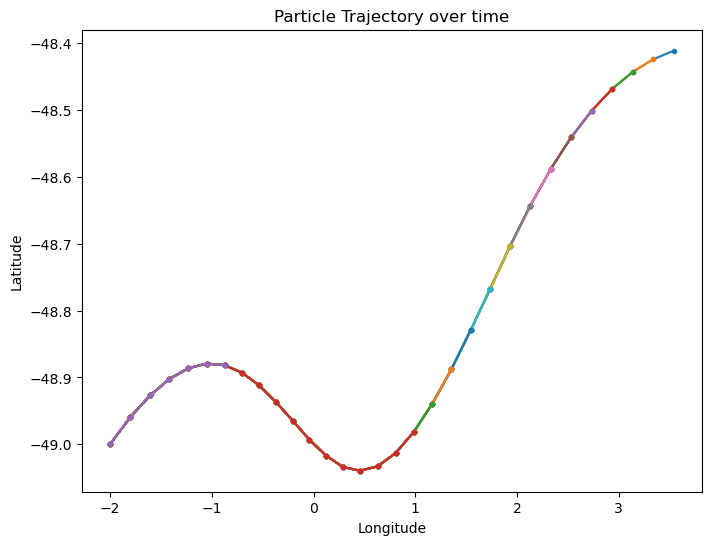

In [47]:
%matplotlib inline
# Plot the particle trajectories
plt.figure(figsize=(8, 6))
plt.plot(pset_traj["lon"].T, pset_traj["lat"].T, ".-")
plt.title("Particle Trajectory over time")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Plot the concentration fields of ALK and DIC at the beginning and the end of the continuous OAE simulation with addition of ALK flux every day at the initial cell

In [48]:
# Define the extent to zoom in on the area of interest
extent = [-3, 5, -50, -48]

# Define the coordinates for the grid
lon = fieldset.V.grid.lon
sample_x = fieldset.U.grid.lon[lon.shape[0]*3//4, :][(fieldset.U.grid.lon[lon.shape[0]*3//4, :] >= extent[0]) & (fieldset.U.grid.lon[lon.shape[0]*3//4, :] <= extent[1])][::2]
sample_y = fieldset.V.grid.lat[:, lon.shape[1]//2][(fieldset.V.grid.lat[:, lon.shape[1]//2] >= extent[2]) & (fieldset.V.grid.lat[:, lon.shape[1]//2] <= extent[3])][::2]

In [49]:
print(f"Concentration of alk forcing particle added to initial cell over time (meq/(m^3s)) : \n {pset_traj['f_alk'].values[0]}")

Concentration of alk forcing particle added to initial cell over time (meq/(m^3s)) : 
 [1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05
 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05
 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05
 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05
 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05 1.2409e-05
 1.2409e-05]


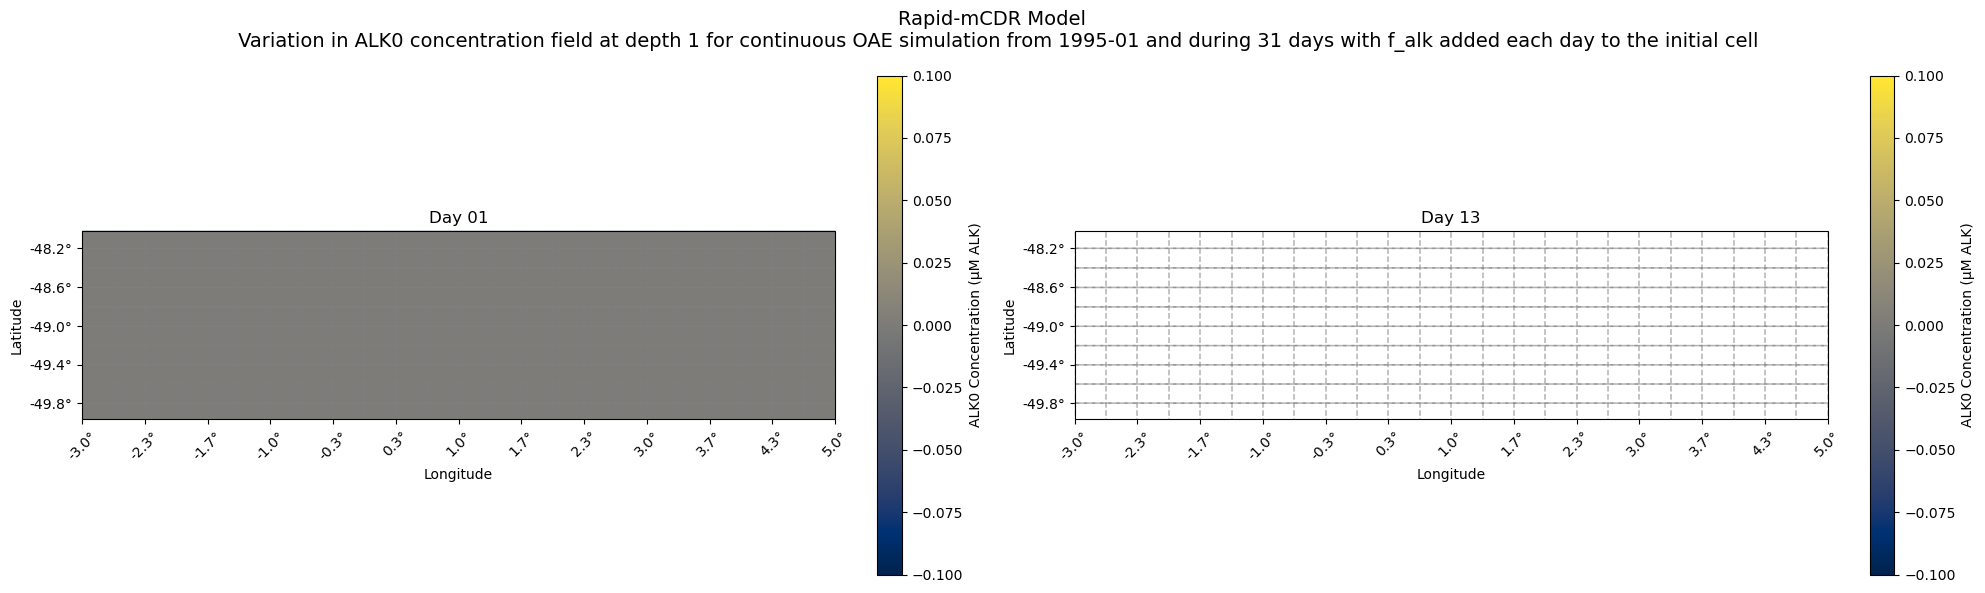

In [51]:
# Define the variable to display
var_name = "ALK0"
particle_name = "f_alk"

# Select the days to display
dayFirst = "0001"
# dayLast = "0496"
dayLast = "0013"

# Load the NetCDF files for each specified days
first = xr.open_dataset(f"{filename}_{dayFirst}{var_name}.nc")
last = xr.open_dataset(f"{filename}_{dayLast}{var_name}.nc")

depth = 1

# Extract the concentration fields for the specified days
fieldF = first[f"{var_name}"].values[0, depth, :, :]  # Level 0 in depth, first time step (date)
fieldL = last[f"{var_name}"].values[0, depth, :, :]

# Masking values of the field where the value is equal to the initial concentration field:
# Areas that have not been modified by the particle, for clearer visualization
fieldL[fieldL == fieldF] = np.nan

# Extract longitude and latitude coordinates
longitudes = first["nav_lon"].values
latitudes = first["nav_lat"].values

%matplotlib inline
fig, axes = plt.subplots(ncols=2, figsize=(20, 6), subplot_kw={'projection': ccrs.PlateCarree()})
fig.suptitle(f"Rapid-mCDR Model \n Variation in {var_name} concentration field at depth {depth} for continuous OAE simulation from {date} and during {last_time} days with {particle_name} added each day to the initial cell", fontsize=14)

end_simu = int(dayLast)%last_time
for ax, fieldDIC, title in zip(axes, [fieldF, fieldL], [f"Day {dayFirst[-2:]}", f"Day {[end_simu + 31 if end_simu == 0 else end_simu][0]}"]):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, edgecolor="black", facecolor="floralwhite")
    ax.set_title(f"{title}")

    # Display the concentration data
    results = ax.pcolormesh(longitudes, latitudes, fieldDIC, transform=ccrs.PlateCarree(), cmap="cividis")
    
    # Add a colorbar for each concentration field
    cbar = fig.colorbar(results, ax=ax, orientation="vertical", fraction=0.05)
    cbar.set_label(f"{var_name} Concentration (µM ALK)")

    # Add gridlines and labels
    ax.set_xticks(sample_x, crs=ccrs.PlateCarree())
    ax.set_yticks(sample_y, crs=ccrs.PlateCarree())
    ax.set_xticklabels([f"{lon:.1f}°" for lon in sample_x], rotation=45)
    ax.set_yticklabels([f"{lat:.1f}°" for lat in sample_y])
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    for i in range(lon.shape[0]):
        ax.plot(fieldset.V.grid.lon[i, :], fieldset.V.grid.lat[i, :], color='gray', linewidth=1.1, linestyle='--', transform=ccrs.PlateCarree(), alpha=0.6)
    for j in range(lon.shape[1]):
        ax.plot(fieldset.U.grid.lon[:, j], fieldset.U.grid.lat[:, j], color='gray', linewidth=1.1, linestyle='--', transform=ccrs.PlateCarree(), alpha=0.6)

# # Display particles as scatter points on the first plot
# particle = axes[0].scatter(
#     pset_traj["lon"].values[0], pset_traj["lat"].values[0], c=pset_traj[f"{particle_name}"].values[0], transform=ccrs.PlateCarree(),
#     s=100, edgecolor="white", cmap="gist_earth"
# )
# 
# # Add a colorbar for particle concentration
# particle_cbar = plt.colorbar(particle, ax=axes[0], orientation="horizontal")
# particle_cbar.set_label(f"Transport of alkalinity {particle_name} added to initial cell over time in zero alkalinity field (meq/(m² s))", fontsize=12)

plt.tight_layout()
plt.show()

In [29]:
fieldF = first[f"{var_name}"].values[0, :, :, :]  # Level 0 in depth, first time step (date)
fieldL = last[f"{var_name}"].values[0, :, :, :]

# Masking values of the field where the value is equal to the initial concentration field:
# Areas that have not been modified by the particle, for clearer visualization
fieldL[fieldL == fieldF] = np.nan

print(f"At the end of the simulation, the total ALK0 field is {np.nansum(fieldL)} µM ALK. This value must match the total ALK flux added each day to the initial cell, after conversion to µM ALK: {np.nansum(pset_traj['f_alk'].values[:, 0] * timedelta(days=1).total_seconds())}")

NameError: name 'last' is not defined

In [30]:
A = np.nansum(fieldL)
B = np.nansum(pset_traj['f_alk'].values[:, 0] * timedelta(days=1).total_seconds())

print(np.abs(A-B))

NameError: name 'fieldL' is not defined

### Volume-weighted mass-conservation check (advection + diffusion)

The finite-volume scheme conserves the **volume-weighted** column mass
$\sum_k h_k\,C_k$ (not the raw sum of concentrations, because cell thicknesses
$h_k$ vary with depth). It should equal the total alkalinity injected into the
surface cell, $h_0\cdot\text{forcing}\cdot\Delta t$ per injection.

In [ ]:
# Volume-weighted conservation check for the finite-volume adv-diff scheme.
# h_fv = tracer cell thicknesses (from the finite-volume setup cell). The scheme
# conserves the volume-weighted column mass  sum_k h_k*C_k  (NOT the raw sum of
# concentrations, because cell thickness varies strongly with depth).
field_last = last[f"{var_name}"].values[0, :, :, :]        # (depth, y, x) final ALK0
mass_model = np.nansum(h_fv[:, None, None] * field_last)    # sum_k h_k * C_k  [uM*m]

mass_per_injection = h_fv[0] * fieldset.alkalinity_forcing * timedelta(days=1).total_seconds()
print(f"Volume-weighted model mass  sum(h_k*C_k) = {mass_model:.6e} uM*m")
print(f"Mass per surface injection  h0*forcing*dt = {mass_per_injection:.6e} uM*m")
print(f"=> effective number of surface injections = {mass_model / mass_per_injection:.3f}  (expected ~ last_time = {last_time})")

# A new particle is injected at the source each day and deposits one dose on its
# release day (particle.released flag), so the effective count should equal the
# number of simulated days. The finite-volume transport conserves mass exactly, so
# sum(h_k*C_k) = last_time * h0*forcing*dt.
